In [1]:
import nltk
nltk.download('wordnet') #This is another language model for another library for English. Use nltk.download('omw-1.4') for Italian


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\AliAGHAZADEHARDEBILI\AppData\Roaming\nltk_dat
[nltk_data]     a...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
from emoatlas import EmoScores #We Import the Library

In [3]:
emos = EmoScores() # This is needed to setup the package

In [8]:
# sample_text = """Stereotype threat, a phenomenon where individuals are at risk of confirming their pre-existing beliefs or expectations, can have a profound impact on students' performance in STEM fields. It is particularly challenging for women and underrepresented groups, who may face discrimination, bias, and stereotypes that can undermine their confidence and potential for success. Addressing stereotype threat is crucial to promote diversity, equity, and inclusion in STEM education and the workforce. However, it requires a multifaceted approach that involves challenging and changing cultural norms, providing supportive environments, and fostering a culture of inclusivity and respect. By taking these steps, we can empower students from all backgrounds to pursue their passions and reach their full potential in STEM fields"""

sample_text = """As a retired university professor living in Rome with a background in humanities and a deep appreciation for evidence-based discourse, I've observed how conversations around healthcare and vaccines can quickly become polarized. My own experience with the pandemic taught me that the most effective approach to managing these discussions isn't about winning arguments but fostering understanding through shared humanity. Having spent time both in academic settings and community spaces, I've found that people often feel most vulnerable when discussing health topics—especially when they're emotionally invested or have experienced personal loss. For instance, during the initial vaccine rollout, I witnessed how misinformation could spread faster than factual information, particularly on social media platforms where people share concerns about side effects or efficacy. To navigate this, I focus on active listening: when someone expresses anxiety about vaccines, I acknowledge their feelings first before offering information. This helps build trust without dismissing their concerns. Additionally, I draw on my background in interdisciplinary studies to frame discussions around universal values—like protecting vulnerable populations or ensuring equitable access to healthcare—to shift the conversation from fear to collective responsibility. My Hindu upbringing also emphasizes compassion and non-discrimination, which guides me to avoid stigmatizing language. In today's digital age, where misinformation can spread rapidly, it's crucial to prioritize empathy over ideology. By grounding discussions in shared goals—such as safeguarding public health and supporting those who are most at risk—we can transform heated debates into constructive dialogues. Ultimately, managing vaccine discussions requires patience, humility, and a commitment to understanding the human stories behind the statistics."""


fmnt = emos.formamentis_network(sample_text)

In [9]:
edgesList = fmnt.edges
verticesList = fmnt.vertices


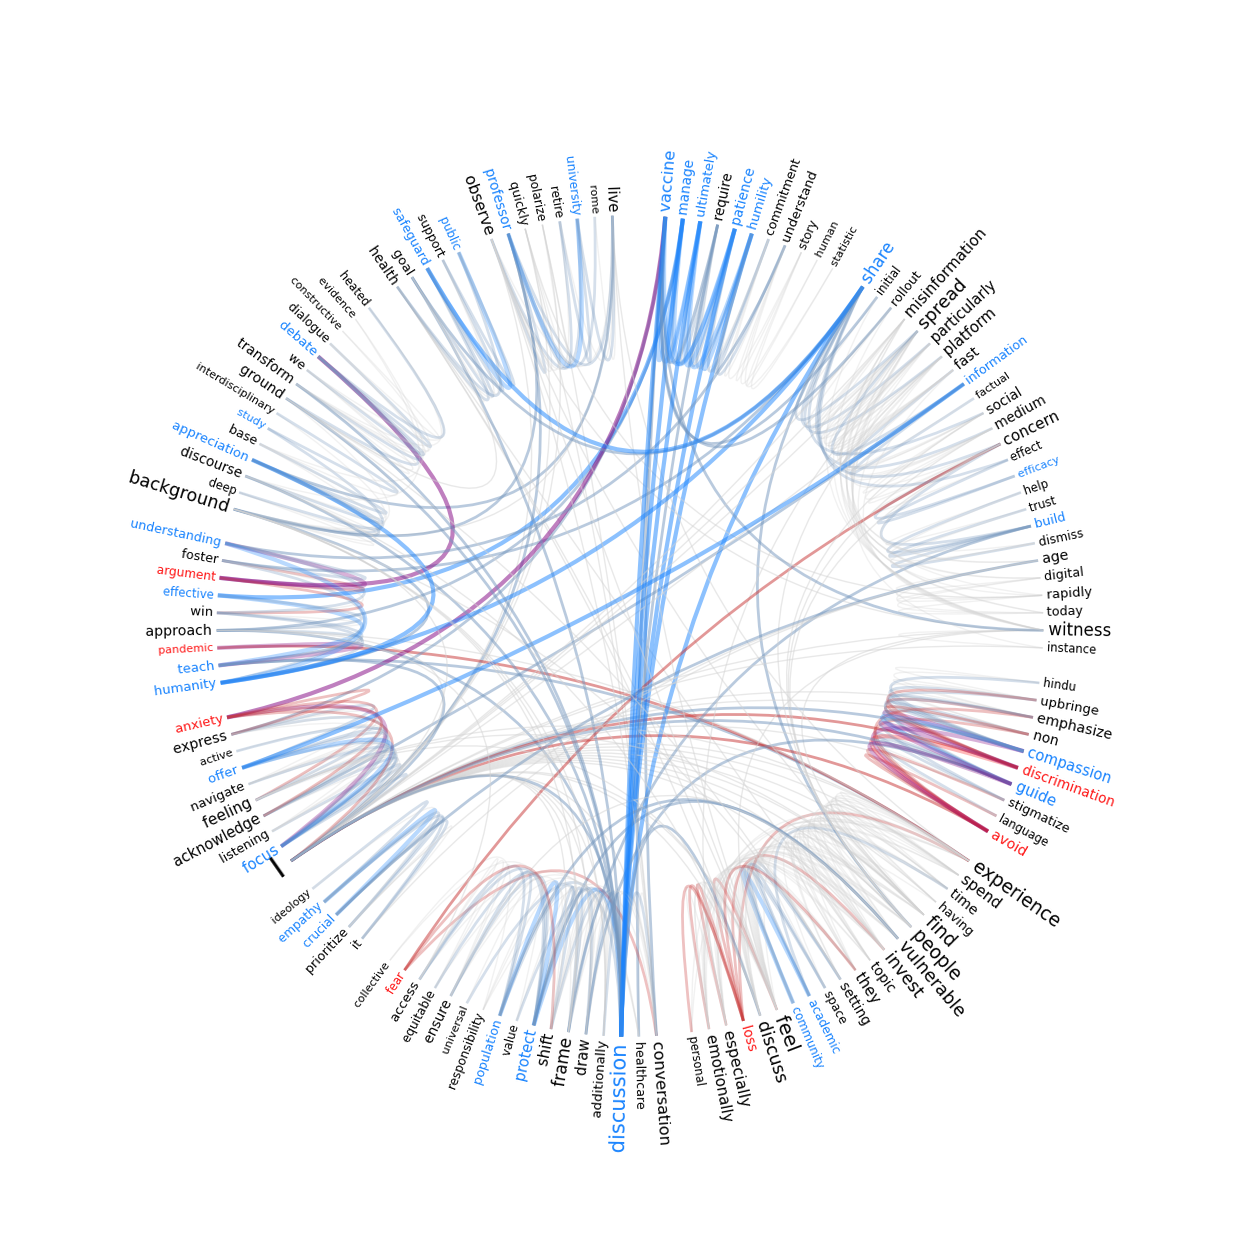

In [10]:
emos.draw_formamentis(
    fmn=fmnt,
    alpha_syntactic=0.5,
    alpha_hypernyms=0.5,
    alpha_synonyms=0.0,
    thickness=1
)

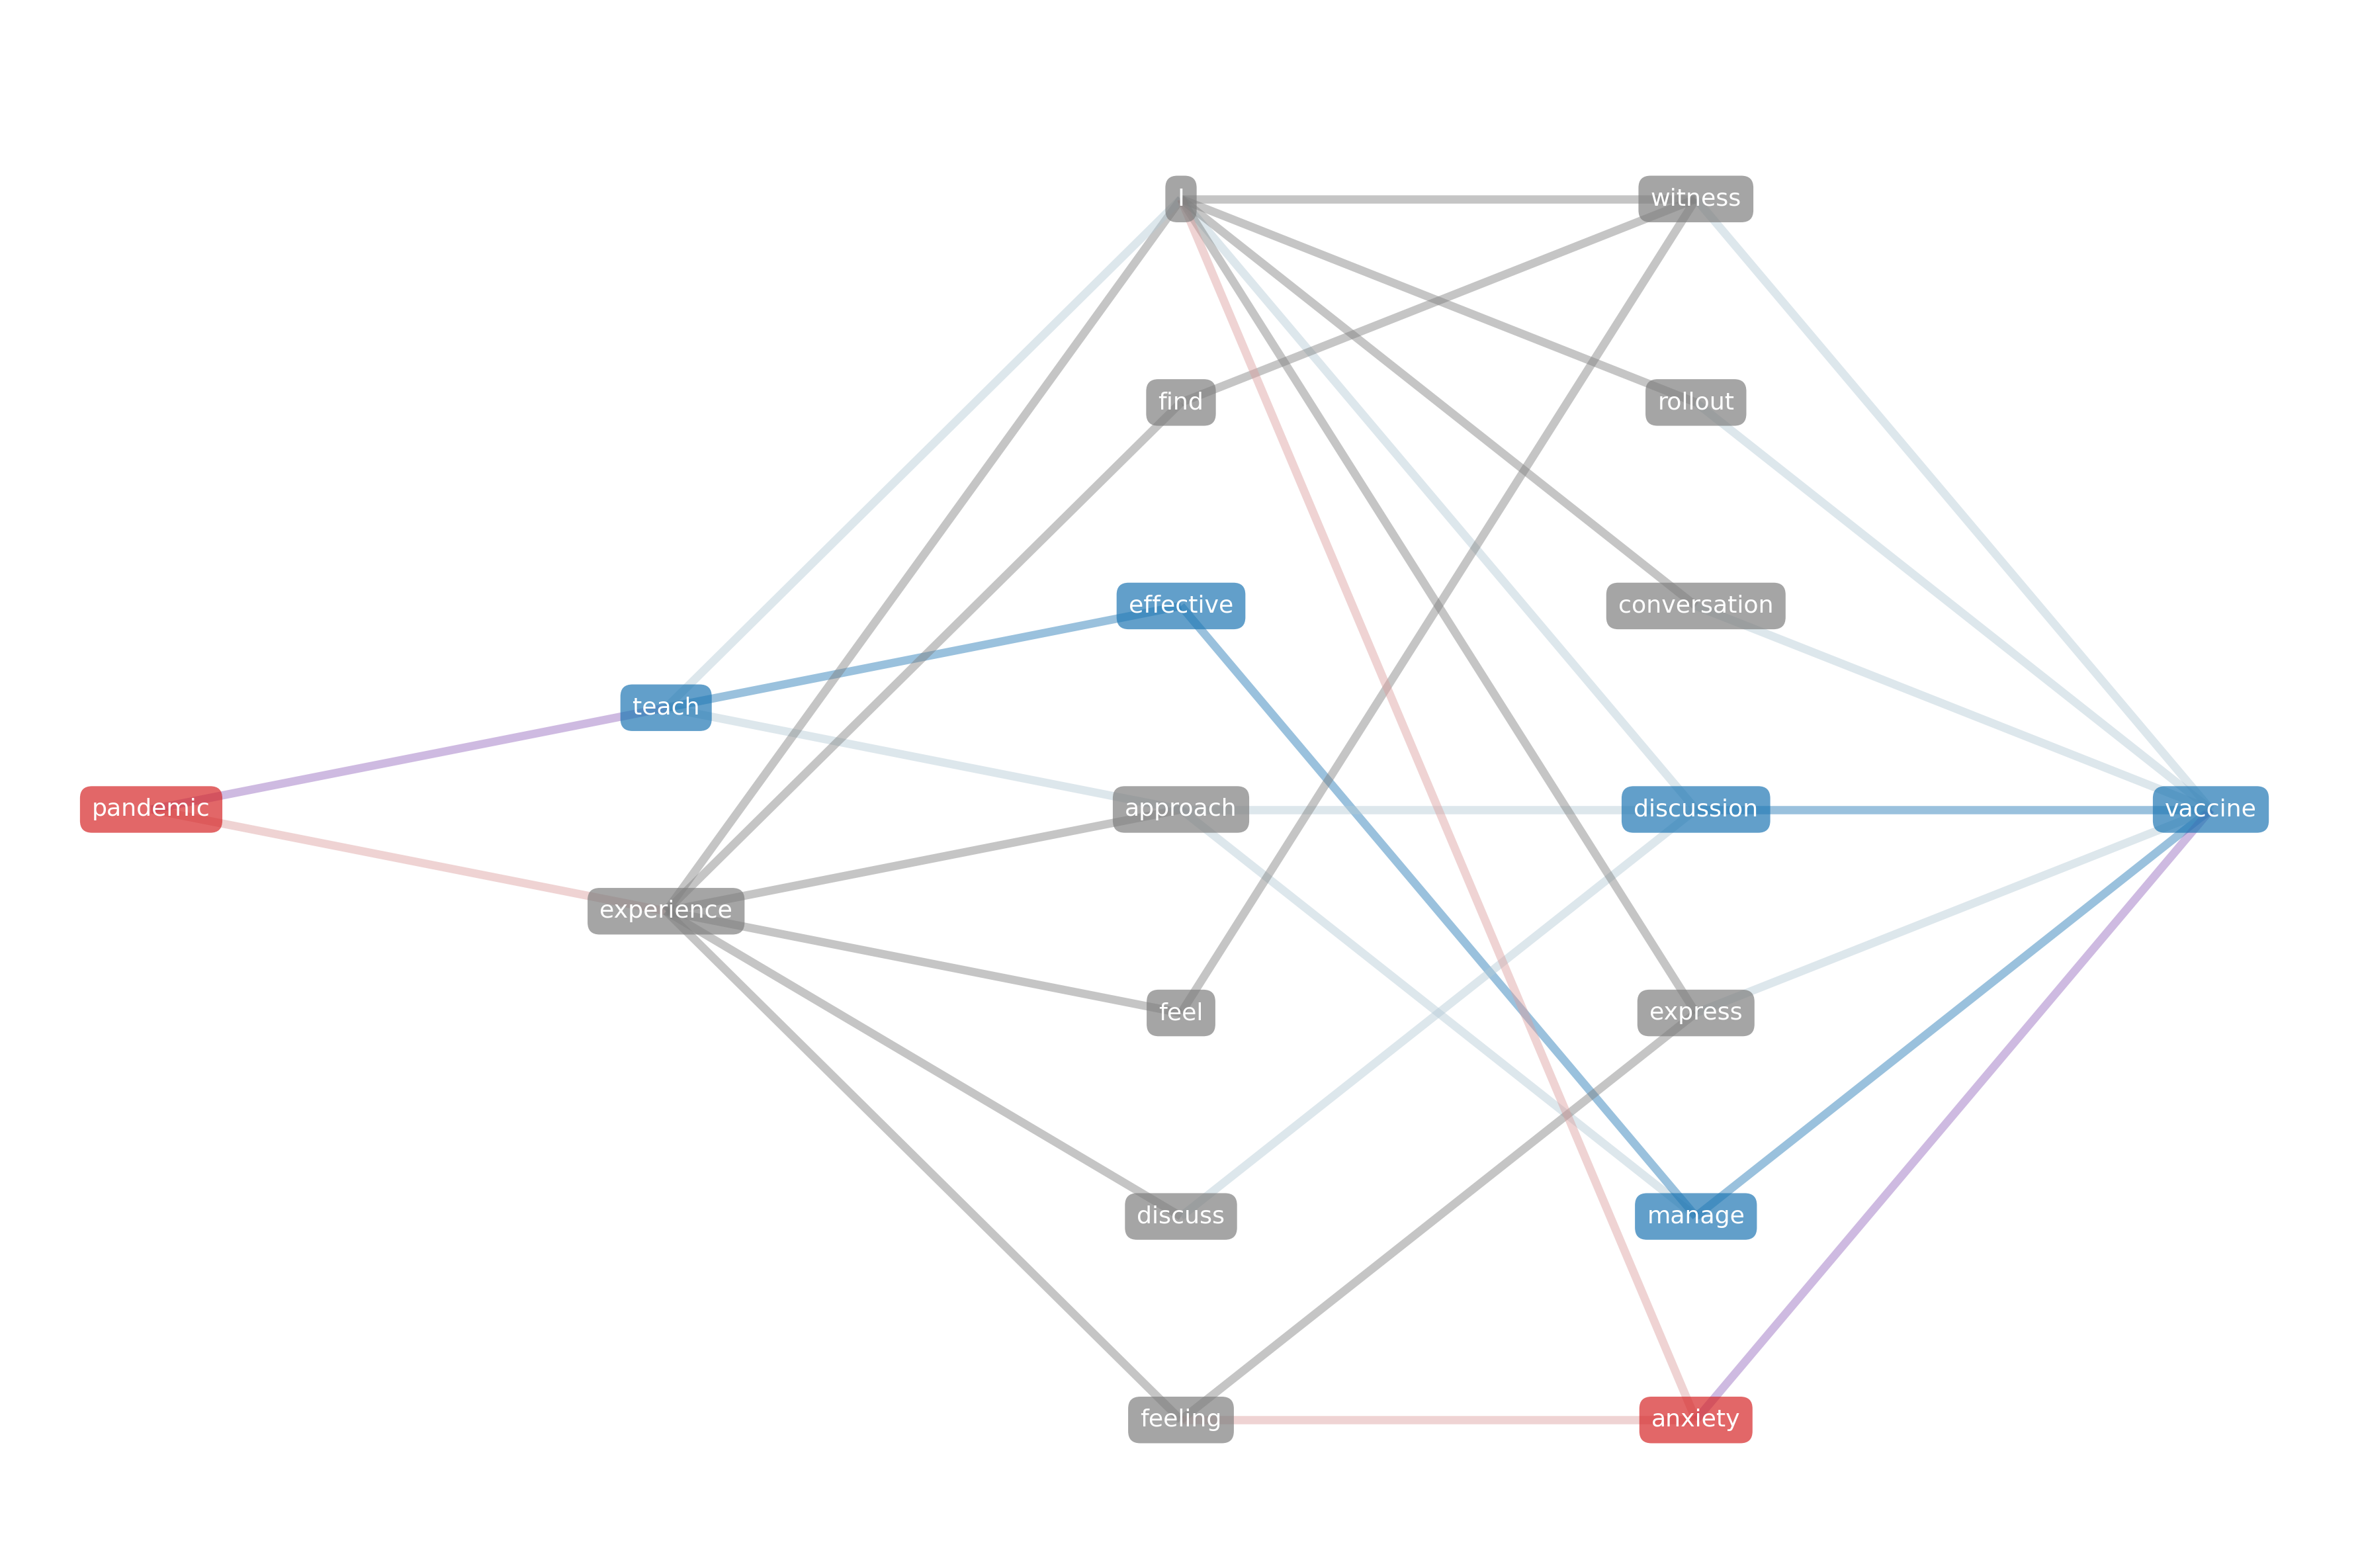

In [11]:
emos.plot_mindset_stream(fmnt,start_node="pandemic", end_node="vaccine")

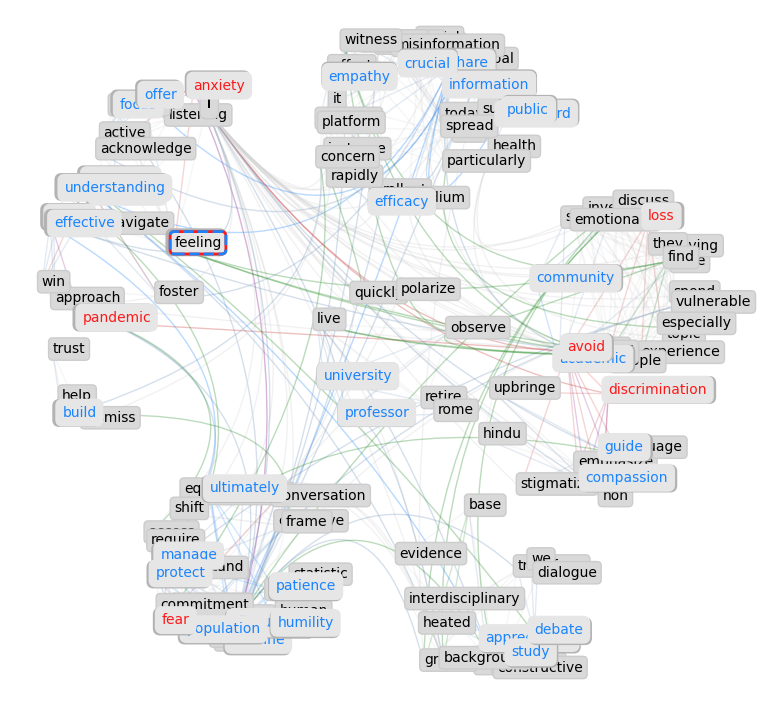

In [19]:
# Displaying different types of edges in a force layout.
# fmnt = emos.formamentis_network(sample_text, semantic_enrichment=['synonyms','hypernyms'], multiplex=True)
fmnt = emos.formamentis_network(sample_text, semantic_enrichment=['synonyms'], multiplex=True)
emos.draw_formamentis(fmnt,layout='force_layout')

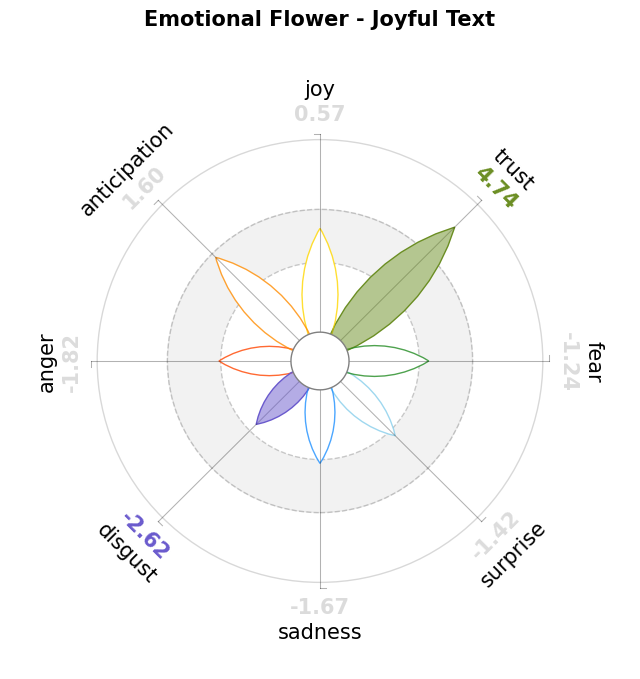

In [20]:
# positive_text
# sample_text = (
#     "Today was absolutely wonderful. I am so grateful to have friends who care and support me. The sunshine, the laughter, the kindness—I feel inspired and full of hope."
# )

emos.draw_formamentis_flower(
    text=sample_text,
    title="Emotional Flower - Joyful Text"
)

In [46]:
fmnt_failure = emos.extract_word_from_formamentis(fmnt, "vaccine")
fmnt_failure


FormamentisNetwork(edges={'syntactic': [('conversation', 'healthcare'), ('conversation', 'vaccine'), ('healthcare', 'vaccine'), ('initial', 'rollout'), ('initial', 'vaccine'), ('express', 'vaccine'), ('anxiety', 'vaccine'), ('ultimately', 'vaccine'), ('discussion', 'require'), ('discussion', 'patience'), ('manage', 'vaccine'), ('manage', 'require'), ('manage', 'patience'), ('discussion', 'manage'), ('rollout', 'witness'), ('initial', 'witness'), ('vaccine', 'witness'), ('rollout', 'vaccine'), ('anxiety', 'express'), ('conversation', 'discussion'), ('patience', 'require'), ('require', 'ultimately'), ('discussion', 'ultimately'), ('patience', 'ultimately'), ('manage', 'ultimately'), ('discussion', 'vaccine'), ('require', 'vaccine'), ('patience', 'vaccine')], 'synonyms': [], 'hypernyms': []}, vertices=['rollout', 'discussion', 'initial', 'conversation', 'patience', 'anxiety', 'vaccine', 'ultimately', 'express', 'healthcare', 'witness', 'manage', 'require'])

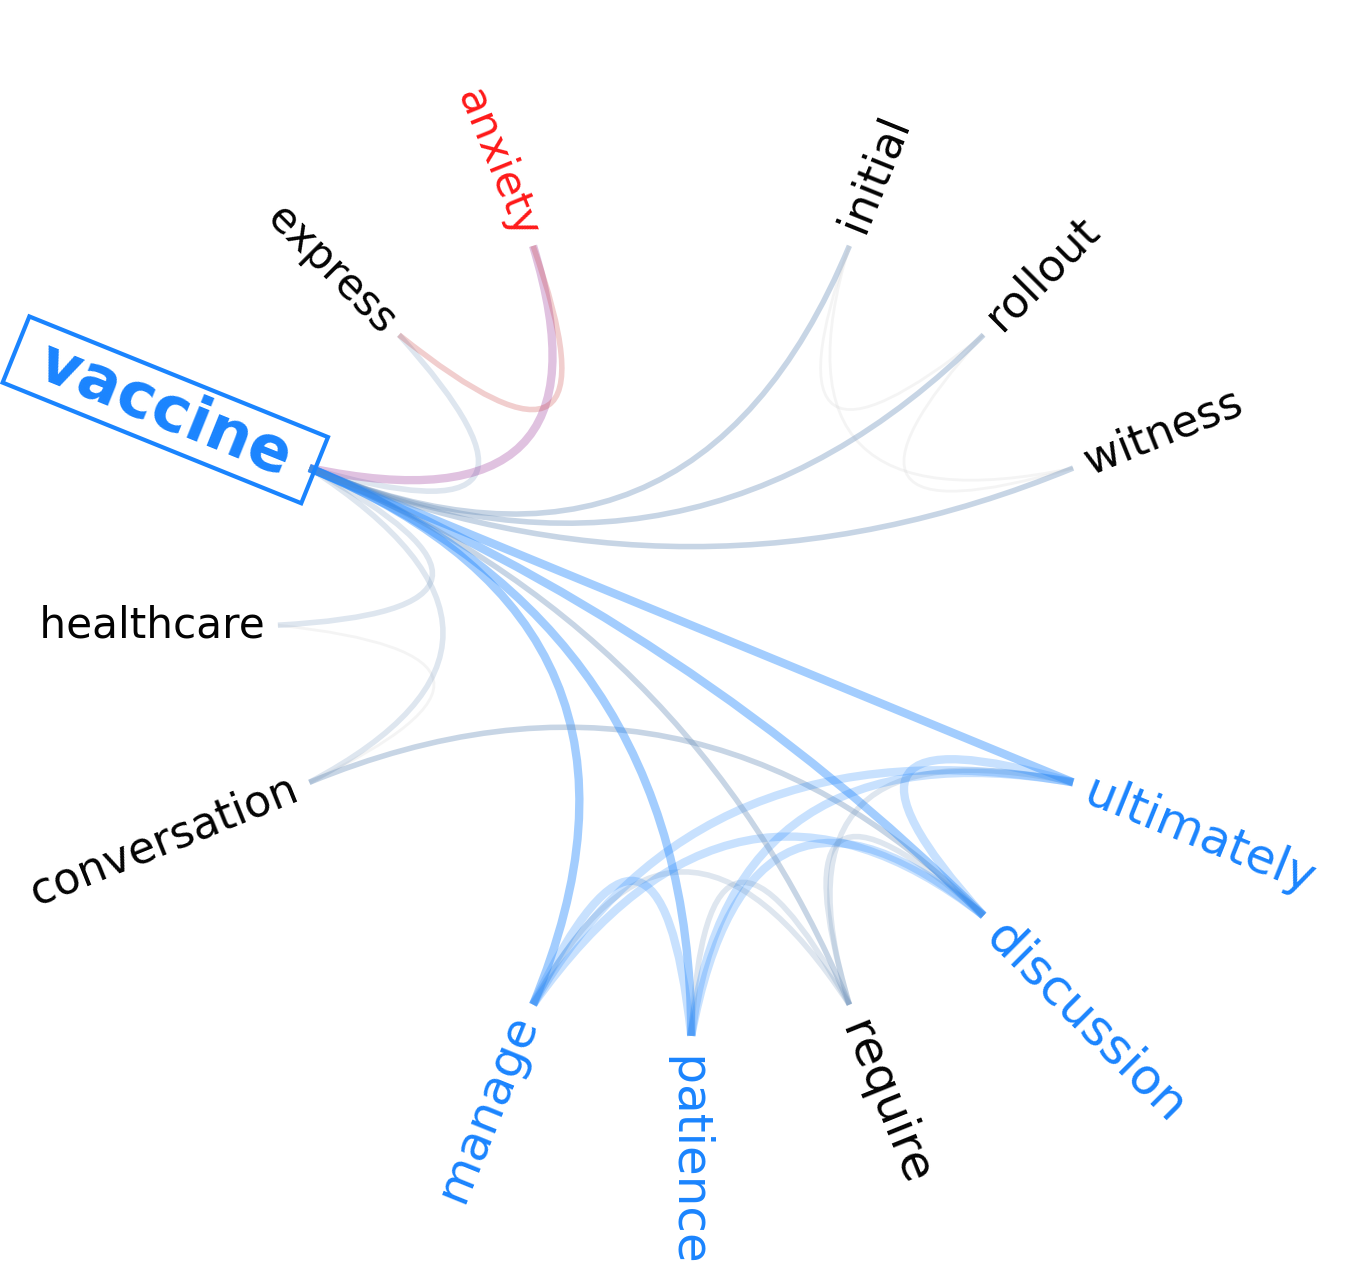

In [50]:
emos.draw_formamentis(
    fmn=fmnt_failure,
    highlight="vaccine",
    alpha_syntactic=0.4,
    alpha_hypernyms=0,
    alpha_synonyms=0,
    thickness=2,
)

**igraph** 

In [42]:
import igraph as ig
from collections import Counter

In [43]:
# create graph for igraph

g = ig.Graph.TupleList(
    edgesList,
    directed=False,
    vertex_name_attr="name",
)

missing = set(verticesList) - set(g.vs["name"])
if missing:
    g.add_vertices(list(missing))

In [44]:
# mode="in"/"out"/"all"
deg = g.degree(mode="all")  # degree for every vertex
deg_centrality = [d / (g.vcount() - 1) for d in deg]  # common normalization
deg_centrality

[0.13793103448275862,
 0.13793103448275862,
 0.08620689655172414,
 0.06896551724137931,
 0.05172413793103448,
 0.08620689655172414,
 0.06896551724137931,
 0.06896551724137931,
 0.06896551724137931,
 0.08620689655172414,
 0.10344827586206896,
 0.08620689655172414,
 0.15517241379310345,
 0.10344827586206896,
 0.15517241379310345,
 0.05172413793103448,
 0.10344827586206896,
 0.13793103448275862,
 0.08620689655172414,
 0.15517241379310345,
 0.13793103448275862,
 0.05172413793103448,
 0.13793103448275862,
 0.1724137931034483,
 0.10344827586206896,
 0.10344827586206896,
 0.05172413793103448,
 0.08620689655172414,
 0.06896551724137931,
 0.10344827586206896,
 0.08620689655172414,
 0.06896551724137931,
 0.10344827586206896,
 0.05172413793103448,
 0.06896551724137931,
 0.1724137931034483,
 0.10344827586206896,
 0.1724137931034483,
 0.15517241379310345,
 0.10344827586206896,
 0.1206896551724138,
 0.06896551724137931,
 0.08620689655172414,
 0.15517241379310345,
 0.06896551724137931,
 0.12068965517